# Resolution Calibration: calibrate → pin → fit

A measured resonance dip is broadened by several separate effects: the **instrument
resolution** (a beamline property), **Doppler** broadening (sample temperature),
**background/normalization**, and **self-shielding/scattering** in black resonances.
On one spectrum these trade off, so the instrument resolution must be characterized
on a *known* standard and then held fixed when fitting unknown samples.

This notebook shows the three resolution models and the **calibrate → pin → fit**
workflow. See also the [Instrument Resolution & Calibration](../../../docs/guide/src/resolution-calibration.md) guide.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import nereids

plt.rcParams['figure.figsize'] = (10, 5)
rng = np.random.default_rng(0)

hf = nereids.load_endf(72, 177)          # Hf-177 (downloads/caches on first run)
energies = np.linspace(2.0, 30.0, 2000)  # eV
FLIGHT_PATH_M = 25.0
print(hf)

ResonanceData(Z=72, A=177, AWR=175.423, n_resonances=180)


## 1. Three resolution models

All three are passed to `forward_model` (and the fitters) the same way; only the
kernel *source* differs. Here we build an **Ikeda–Carpenter** analytic model and a
**Gaussian**, and use `ic.as_tabulated()` as a tabulated kernel (the same form a
Monte-Carlo `load_resolution(...)` file would give).

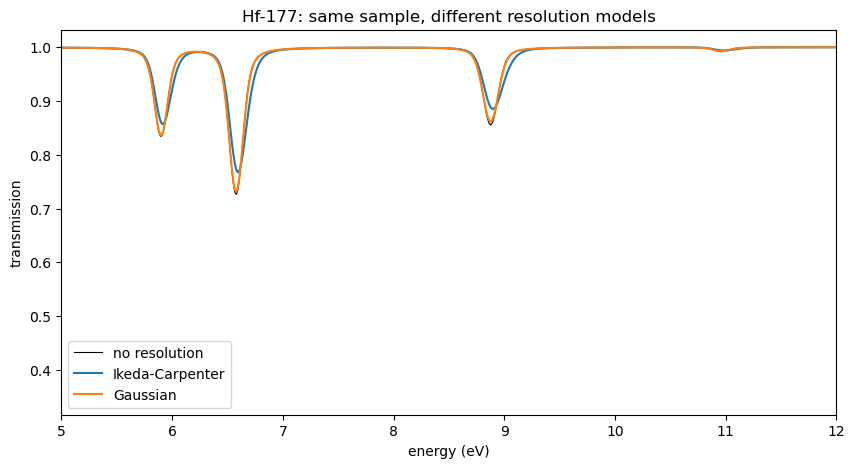

In [2]:
# Ikeda-Carpenter analytic moderator model
ic = nereids.IkedaCarpenter(
    flight_path_m=FLIGHT_PATH_M, e_min_ev=0.5e-3, e_max_ev=1000.0,
    alpha=nereids.EnergyLaw.sqrt_e(0.30, 0.0),   # alpha(E) = 0.30 * sqrt(E)
    beta=0.10,
    r=nereids.EnergyLaw.exp_mev(25.0),           # storage fraction -> 0 in the eV regime
)
ic_kernel = ic.as_tabulated()        # a TabulatedResolution

rho = 2e-5  # low density -> non-black dips (T_min in the 0.2-0.8 calibration range)
T_none = np.asarray(nereids.forward_model(energies, [(hf, rho)], temperature_k=300.0))
T_ic   = np.asarray(nereids.forward_model(energies, [(hf, rho)], temperature_k=300.0, resolution=ic_kernel))
T_gau  = np.asarray(nereids.forward_model(energies, [(hf, rho)], temperature_k=300.0,
                                          flight_path_m=FLIGHT_PATH_M, delta_t_us=1.0, delta_l_m=1e-3))

fig, ax = plt.subplots()
ax.plot(energies, T_none, 'k-', lw=0.8, label='no resolution')
ax.plot(energies, T_ic, label='Ikeda-Carpenter')
ax.plot(energies, T_gau, label='Gaussian')
ax.set_xlim(5, 12); ax.set_xlabel('energy (eV)'); ax.set_ylabel('transmission')
ax.set_title('Hf-177: same sample, different resolution models'); ax.legend(); plt.show()

## 2. Calibrate the resolution on a known-(ρ,T) calibrant

We simulate a calibrant whose **true** resolution is the IC kernel, at known density
and temperature, with Poisson noise. `calibrate_resolution` fits each model family's
resolution parameters with ρ and T **fixed**. By default the energy scale is
**pinned** (`fit_t0=fit_l_scale=False`) — a pure shape/width fit on the (here
exactly known) nominal grid. A genuinely *wrong-shaped* model (a symmetric Gaussian
vs an asymmetric moderator tail) is then distinguished by a higher χ². Caveat
for this synthetic demo: the `udr_corr` arm is handed the **exact truth kernel** as
its base and the IC arm *is* the truth shape, so their χ²≈1 are
loop-closure smoke tests, not independent shape identification — only the Gaussian
arm is a genuinely different shape. **And the position is known here only because the
data is synthetic** — see the note after the fit on why real-data family
discrimination is weaker.

In [3]:
# Synthetic calibrant: truth = the IC kernel, at known rho,T, non-black
n_ob = 1e5
counts = rng.poisson(n_ob * np.clip(T_ic, 0, None))
cal_data = counts / n_ob
cal_unc = np.sqrt(np.maximum(counts, 1.0)) / n_ob
print(f"calibrant T_min = {cal_data.min():.3f}  (non-black)")

results = {}
for family, extra in [("ic", {}), ("udr_corr", {"base_udr": ic_kernel}), ("gaussian", {})]:
    cal = nereids.calibrate_resolution(
        energies, cal_data, cal_unc, family,
        isotopes=[(hf, rho)], temperature_k=300.0, restarts=2, **extra,
    )
    results[family] = cal
    print(f"  {family:9s}  chi2/dof = {cal.chi2:6.3f}   params = {cal.params()}")

best = min(results, key=lambda f: results[f].chi2)
print(f"\nbest-fit family (lowest chi2): {best!r}  <- this is the instrument's resolution shape")

calibrant T_min = 0.371  (non-black)


  ic         chi2/dof =  0.990   params = {'a0': 0.2860290047436961, 'a1': 0.04114861696958344}


  udr_corr   chi2/dof =  0.991   params = {'s0': 0.986628559873467, 'p': 0.010685993213682445}


  gaussian   chi2/dof =  4.750   params = {'delta_t_us': 0.01822968488980925, 'delta_l_m': 0.12215697361002933}

best-fit family (lowest chi2): 'ic'  <- this is the instrument's resolution shape


The **Gaussian** cannot reproduce the asymmetric moderator tail, so with the energy
scale pinned it stays distinguished at χ²>1. This synthetic calibrant was
generated at the nominal position, so pinning `(t0, L_scale)` is exactly right and the
χ² charges the Gaussian for *both* shape and the asymmetric centroid lag.

**On real data this discrimination is optimistic.** The mode→centroid lag is pure
1/√E — the same basis as a flight-path (`L_scale`) error — so absolute
dip position cannot separate an asymmetric kernel from a small `L` miscalibration. If
you fit the shared energy scale (`fit_t0=True, fit_l_scale=True`) *without* a tight
metrology prior, the Gaussian buys back most of that margin and the families become
hard to tell apart; the honest, position-independent discriminator is only the
*skew/tail*. Fit `(t0, L_scale)` under a Gaussian prior from your flight-path / timing
metrology, and report discrimination as a function of the prior strength.

The IC and width-corrected-UDR arms fit at χ²≈1, but they are handed the
truth shape (IC *is* the truth; udr_corr is given the truth kernel as its base), so
those are loop-closure checks. On real data you would compare candidate models that are
**not** the data-generating process.

## 3. Pin the calibrated resolution and fit a sample

Now switch to an unknown sample (different density, warmer) measured on the **same
beamline**. We pin the calibrated resolution and fit density *and* temperature jointly.

In [4]:
# Unknown sample: higher density, warm (truth rho=1.2e-4, T=450 K), lower statistics
T_sample = np.asarray(nereids.forward_model(energies, [(hf, 1.2e-4)], temperature_k=450.0, resolution=ic_kernel))
sc = rng.poisson(2e4 * np.clip(T_sample, 0, None))
samp_data = sc / 2e4
samp_unc = np.sqrt(np.maximum(sc, 1.0)) / 2e4

# Pin the calibrated resolution and fit rho AND T. The udr_corr / ic families
# expose a tabulated kernel via as_tabulated(); the gaussian family has no kernel
# (as_tabulated() -> None) and pins through its (delta_t_us, delta_l_m) timing
# parameters instead.
if best == "gaussian":
    dt_us, dl_m = results[best].gaussian_params()
    fit = nereids.fit_spectrum_typed(
        samp_data, samp_unc, energies, [(hf, 8e-5)],
        temperature_k=350.0, fit_temperature=True,   # recover rho AND T
        flight_path_m=FLIGHT_PATH_M, delta_t_us=dt_us, delta_l_m=dl_m, max_iter=300,
    )
else:
    pinned = results[best].as_tabulated()      # the calibrated resolution
    fit = nereids.fit_spectrum_typed(
        samp_data, samp_unc, energies, [(hf, 8e-5)],
        temperature_k=350.0, fit_temperature=True,   # recover rho AND T
        resolution=pinned, max_iter=300,
    )
print(f"recovered density     = {float(np.asarray(fit.densities)[0]):.3e}  (truth 1.20e-4)")
print(f"recovered temperature = {fit.temperature_k:.0f} K        (truth 450 K)")
print(f"reduced chi-squared   = {fit.reduced_chi_squared:.2f}")

recovered density     = 1.202e-04  (truth 1.20e-4)
recovered temperature = 446 K        (truth 450 K)
reduced chi-squared   = 1.08


## Takeaways

- **Calibrate on a deep, non-black standard** (T_min ≈ 0.2–0.8) — the calibration χ²
  rejects genuinely wrong-shaped resolution models. (This synthetic example is
  loop-closed for the IC/udr_corr arms; on real data, compare candidate models
  against the measured calibrant.)
- **Density / isotopic characterization is robust** to the resolution-model choice;
  **temperature is sensitive** — calibrate before trusting a fitted temperature.
- **Pin** the calibrated resolution and re-fit background/normalization per sample;
  the resolution and flight path transfer, the rest do not.
- **The resolution *width* is well-determined; the *family* is not, from a calibrant
  alone.** The `ic` kernel anchors its mode at zero offset; its right-skewed centroid
  lags by ~1/α(E) — pure 1/√E, the **same basis as a flight-path
  (`L_scale`) error** — so absolute dip position cannot distinguish an asymmetric
  kernel from a small `L` miscalibration. `calibrate_resolution` **pins** the energy
  scale by default (a pure shape/width fit). To handle position honestly, fit the
  *shared* `(t0, L_scale)` under a metrology prior (`fit_t0=True, fit_l_scale=True,
  t0_prior_us=…, l_scale_prior=…`; reported as `cal.position_t0_us` /
  `cal.position_l_scale` / `cal.prior_penalty`). Do **not** fit position with a flat
  prior — a free `L_scale` absorbs the lag and corrupts the width.

A poor (black-resonance) calibrant soaks self-shielding/scattering into the fitted
"resolution" and will not transfer — choose calibrants whose resonances stay non-black.